In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('alex_paper.mplstyle')
import compute_S_rate
from scipy import sparse
import networkx as nx
from TemporalNetwork import StaticTempNetwork
from scipy.sparse import csr_matrix
from scipy.stats import wasserstein_distance
import auxiliary_functions

Could not load cython functions. Some functionality might be broken.
Could not load sparse_dot_mkl. Will use scipy.sparse for matrix products.


In [2]:
#Closed Formula Heat Diffussion Complete Graph
H_Heat = lambda t, n: np.log(n) - (n-1)/n*np.exp(-(n*t))*np.log((1+(n-1)*np.exp(-(n*t))) / (1-np.exp(-(n*t)))) - (n-1)/n * np.log(1-np.exp(-(n*t))) - 1/n*np.log(1+ (n-1)*np.exp((-n*t)))

In [3]:
def heat_kernel_path_graph(N: int, t: float) -> np.ndarray:
    """
    Return the heat‑diffusion transition matrix e^{−tL} for the simple path
    graph P_N (vertices 0,…,N−1 with edges i–(i+1)).

    Parameters
    ----------
    N : int
        Number of vertices of the path graph.
    t : float
        Diffusion time (non‑negative).

    Returns
    -------
    T : ndarray, shape (N, N)
        Row‑stochastic transition matrix whose (i, j) entry gives
        the probability of being at vertex j at time t when starting
        from vertex i.
    """
    # Eigenvalues λ_k = 2(1 − cos(π k / N)),  k = 0,…,N−1
    k = np.arange(N)
    lambdas = 2.0 * (1.0 - np.cos(np.pi * k / N))

    # Eigenvectors:
    #   – k = 0: constant vector (normalised)
    #   – k ≥ 1: DST‑II cosine modes with a half‑shift (j + 0.5)
    j = np.arange(N).reshape(-1, 1)          # column of vertex indices
    U0 = np.ones((N, 1)) / np.sqrt(N)        # constant eigenvector
    k1 = np.arange(1, N).reshape(1, -1)      # row of mode indices
    U_rest = np.sqrt(2.0 / N) * np.cos(np.pi * k1 * (j + 0.5) / N)

    U = np.hstack((U0, U_rest))              # full eigenvector matrix (orthonormal)

    # Heat kernel: U · diag(e^{−λ_k t}) · Uᵀ
    T = (U * np.exp(-lambdas * t)) @ U.T

    # Numerical clean‑up: set tiny negative round‑off to zero and renormalise rows
    T = np.clip(T, 0.0, None)
    T /= T.sum(axis=1, keepdims=True)

    return sparse.csr_matrix(T)

In [ ]:
def heat_circulant_matrix(n, S, t):
    """
    Heat-transition matrix  e^{-tL}  of the undirected circulant graph C_n(S).

    Parameters
    ----------
    n : int
        Number of vertices (labelled 0 … n-1).
    S : iterable of int
        Positive step sizes (1 ≤ s ≤ ⌊n/2⌋).  Each s adds the edges
        {i, i±s mod n}.  If n is even and n/2∈S, that step contributes
        only ONE neighbour per vertex.
    t : float
        Diffusion (heat) time  t ≥ 0.

    Returns
    -------
    H : ndarray, shape (n, n), dtype=float
        The row-stochastic heat matrix  H = exp(−t L).
    """
    S = {int(s) % n for s in S if s % n != 0}      # sanitise
    # ------------------------------------------------------------
    # 1. first row of the adjacency matrix (length-n circulant vector)
    c = np.zeros(n, dtype=float)
    for s in S:
        c[s] = 1
        opp = (-s) % n
        if opp != s:               # skip the duplicate when s = n/2
            c[opp] = 1
    # degree of every vertex
    d = int(c.sum())
    # ------------------------------------------------------------
    # 2. spectrum of the adjacency matrix via FFT
    λ = np.fft.fft(c)              # length-n array of eigen-values
    # 3. eigen-values of −L = −(dI − A)
    exp_eigs = np.exp(-t * (d - λ))
    # 4. inverse FFT → first row of heat kernel
    h = np.fft.ifft(exp_eigs).real   # numerical imag parts ≈ 0
    # ------------------------------------------------------------
    # 5. build full circulant heat matrix from its first row
    H = np.vstack([np.roll(h, i) for i in range(n)])
    return sparse.csr_matrix(H)

In [ ]:
# Define parameters
N = 50
p_values = [0.1, 0.25, 0.5]
Number_of_graphs = 50
lambda_value = 1.0
time = np.logspace(-4, 4, 100)
p0 = 1 / N * np.ones(N)

# Colors
colors = ['#1a2b3c', "#a91b1b", "#99108E", "#6F134D", "#2D0614"]

# Initialize plot
plt.figure(figsize=(10, 6))

# Complete graph entropy
formula_entropy = [H_Heat(t, N) for t in time]
plt.plot(time, formula_entropy, label="Complete Graph", color=colors[0], alpha=0.8)

# Path graph entropy
Transitions = [heat_kernel_path_graph(N, t) for t in time]
formula_entropy_2 = compute_S_rate.compute_conditional_entropy(
    list_T=Transitions,
    lamda=lambda_value,
    force_csr=True,
    time_domain=list(np.arange(0, len(time) - 1)),
    p0=p0,
)
entropy_path = formula_entropy_2[list(formula_entropy_2.keys())[0]][1:]
plt.plot(time[:-1], entropy_path, label="Path Graph", color=colors[0], linestyle='--', alpha=0.8)

# Mean-field entropy
Transitions = [heat_circulant_matrix(N, {1,2,3}, t) for t in time]
formula_entropy_2 = compute_S_rate.compute_conditional_entropy(
    list_T=Transitions,
    lamda=lambda_value,
    force_csr=True,
    time_domain=list(np.arange(0, len(time) - 1)),
    p0=p0,
)
entropy_path = formula_entropy_2[list(formula_entropy_2.keys())[0]][1:]
plt.plot(time[:-1], entropy_path, label=" Circulant Graph, step-set {1,2,3}", color=colors[1], alpha=0.8)


# Loop over different p-values
for idx, p in enumerate(p_values):
    entropy_matrix = []

    for n_sample in range(Number_of_graphs):
        ws_adj = nx.adjacency_matrix((nx.watts_strogatz_graph(n=N, k=6, p=p, seed=42+n_sample)))
        ws_rw = StaticTempNetwork(times=time, adjacency=sparse.csr_matrix(ws_adj))
        ws_rw.compute_laplacian_matrices(random_walk=False)
        ws_rw.compute_inter_transition_matrices(lamda=lambda_value, dense_expm=False, use_sparse_stoch=False)
        ws_rw.compute_transition_matrices(lamda=lambda_value)

        H_ws_rw = compute_S_rate.compute_conditional_entropy(
            net=ws_rw,
            list_T=ws_rw.T[lambda_value],
            lamda=lambda_value,
            force_csr=True,
            time_domain=list(np.arange(0, len(time) - 1)),
            p0=p0,
        )

        entropy_values = H_ws_rw[list(H_ws_rw.keys())[0]][1:]
        entropy_matrix.append(entropy_values)

    entropy_array = np.array(entropy_matrix)
    mean_entropy = np.mean(entropy_array, axis=0)
    std_entropy = np.std(entropy_array, axis=0)

    # Plot average curve with confidence interval
    plt.plot(time[:-1], mean_entropy, label=f"WS Graphs (p={p})", color=colors[2+idx], linestyle=':', linewidth=2)
    plt.fill_between(time[:-1], mean_entropy - std_entropy, mean_entropy + std_entropy,
                     color=colors[1], alpha=0.2, label=f'p={p} ±1 std dev')
    

# Finalize plot
plt.xlabel("Time (t)")
plt.xscale('log')
plt.ylabel("Entropy (H)")
plt.title(f"Average Entropy Curves for WS Graphs (N={N})")
plt.legend()
plt.tight_layout()

# plt.savefig('/Users/samuelkoovely/Desktop/fig_entropy/average_er_curve_multi_p.png', format='png', dpi=300)
plt.show()

## Plot ER vs Circulant

In [ ]:
# Define parameters
N = 100
p_values = [0.1]
Number_of_graphs = 10
Step_sets = [{1, 2, 3, 4, 13}, {1, 3, 5, 11, 13}, {1, 10, 11, 12, 13}]
lambda_value = 1.0
time = np.logspace(-4, 4, 100)

# Colors
colours = ['#1a2b3c']
colours += auxiliary_functions.generate_random_colors(len(p_values) + len(Step_sets))

# Initialize plot
plt.figure(figsize=(10, 6))

# For storing diameters
diameters_dict = {p: [] for p in p_values}

# Complete graph entropy
formula_entropy = [H_Heat(t, N) for t in time]
plt.plot(time, formula_entropy, label="Complete Graph", color=colours[0], alpha=0.8)

# Path graph entropy
Transitions = [heat_kernel_path_graph(N, t) for t in time]
p0 = 1 / N * np.ones(N)
formula_entropy_2 = compute_S_rate.compute_conditional_entropy(
    list_T=Transitions,
    lamda=lambda_value,
    force_csr=True,
    time_domain=list(np.arange(0, len(time) - 1)),
    p0=p0,
)
entropy_path = formula_entropy_2[list(formula_entropy_2.keys())[0]][1:]
plt.plot(time[:-1], entropy_path, label="Path Graph", color=colours[0], linestyle='--', alpha=0.8)

# Loop over ER graphs with different p values
for i, p in enumerate(p_values):
    entropy_matrix = []

    for _ in range(Number_of_graphs):
        G = nx.erdos_renyi_graph(N, p)
        if not nx.is_connected(G):
            G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

        # Diameter of largest connected component
        diameter = nx.diameter(G)
        diameters_dict[p].append(diameter)

        er_adj = nx.adjacency_matrix(G)
        er_rw = StaticTempNetwork(times=time, adjacency=csr_matrix(er_adj))
        er_rw.compute_laplacian_matrices(random_walk=False)
        er_rw.compute_inter_transition_matrices(lamda=1, dense_expm=False, use_sparse_stoch=False)
        er_rw.compute_transition_matrices(lamda=1)

        H_er_rw = compute_S_rate.compute_conditional_entropy(
            net=er_rw,
            list_T=er_rw.T[1],
            lamda=1,
            force_csr=True,
            time_domain=list(np.arange(0, len(time) - 1)),
            p0=p0,
        )

        entropy_values = H_er_rw[list(H_er_rw.keys())[0]][1:]  # discard t=0
        entropy_matrix.append(entropy_values)

    # Convert to array and compute statistics
    entropy_array = np.array(entropy_matrix)
    mean_entropy = np.mean(entropy_array, axis=0)
    std_entropy = np.std(entropy_array, axis=0)

    # Plot average curve with confidence interval
    plt.plot(time[:-1], mean_entropy, label=f"ER Graphs p={p}", color=colours[i + 1], linestyle=':', linewidth=2)
    plt.fill_between(time[:-1], mean_entropy - std_entropy, mean_entropy + std_entropy,
                     color=colours[i + 1], alpha=0.2)
    
    # Loop over different circulant graphs
    for j, s in enumerate(Step_sets):
        # Compute entropy
        Transitions = [heat_circulant_matrix(N, s, t) for t in time]
        p0 = p0 = 1/N*np.ones(N)
        formula_entropy_circulant = compute_S_rate.compute_conditional_entropy(list_T=Transitions, lamda=lambda_value, force_csr=True, time_domain=list(np.arange(0, len(time) - 1)), p0=p0)
        plt.plot(time[:-1], formula_entropy_circulant[list(formula_entropy_circulant.keys())[0]][1:], label=f"Formula Circulant Graph, step-set {s}", color=colours[i+j+1], linestyle=':', alpha=0.8)

# Finalize plot
plt.xlabel("Time (t)")
plt.xscale('log')
plt.ylabel("Entropy (H)")
plt.title(f"ER Graphs  vs Circulant Graphs (N={N})")
plt.legend()
plt.tight_layout()
plt.show()

# Output diameters
for p, diam_list in diameters_dict.items():
    mean_diam = np.mean(diam_list)
    print(f"p={p:.2f} → Avg. diameter over {Number_of_graphs} samples: {mean_diam:.2f}")

## Plot together

/Users/samuelkoovely/Documents/GitHub/flow_stability/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/samuelkoovely/Documents/GitHub/flow_stability/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


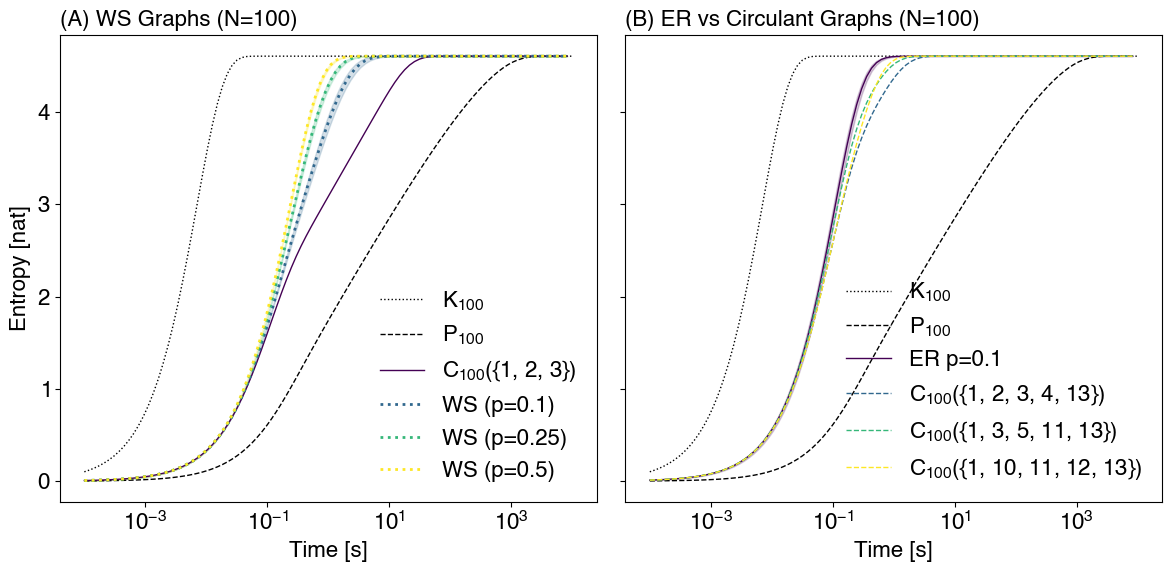

In [ ]:
# ----------------------
# Shared Parameters
# ----------------------
lambda_value = 1.0
time = np.logspace(-4, 4, 100)
N = 100
Number_of_graphs = 10
# ----------------------
# Setup Figure
# ----------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# ----------------------
# Plot 1: WS Graphs vs others
# ----------------------
ax = axes[0]
p_values = [0.1, 0.25, 0.5]
p0 = 1 / N * np.ones(N)
colors = ['k']
colors += auxiliary_functions.generate_viridis_colors(len(p_values) + 1)

# Complete graph
formula_entropy = [H_Heat(t, N) for t in time]
ax.plot(time, formula_entropy, label=r'$K_{100}$', color=colors[0], linestyle=':')

# Path graph
Transitions = [heat_kernel_path_graph(N, t) for t in time]
formula_entropy_2 = compute_S_rate.compute_conditional_entropy(
    list_T=Transitions,
    lamda=lambda_value,
    force_csr=True,
    time_domain=list(np.arange(0, len(time) - 1)),
    p0=p0,
)
entropy_path = formula_entropy_2[list(formula_entropy_2.keys())[0]][1:]
ax.plot(time[:-1], entropy_path, label=r"$P_{100}$", color=colors[0], linestyle='--')

# Circulant graph
Transitions = [heat_circulant_matrix(N, {1, 2, 3}, t) for t in time]
formula_entropy_2 = compute_S_rate.compute_conditional_entropy(
    list_T=Transitions,
    lamda=lambda_value,
    force_csr=True,
    time_domain=list(np.arange(0, len(time) - 1)),
    p0=p0,
)
entropy_circ = formula_entropy_2[list(formula_entropy_2.keys())[0]][1:]
ax.plot(time[:-1], entropy_circ, label=fr"$C_{{{N}}}$({{1, 2, 3}})", color=colors[1])

# WS Graphs
for idx, p in enumerate(p_values):
    entropy_matrix = []

    for n_sample in range(Number_of_graphs):
        ws_adj = nx.adjacency_matrix((nx.watts_strogatz_graph(n=N, k=6, p=p, seed=42+n_sample)))
        ws_rw = StaticTempNetwork(times=time, adjacency=sparse.csr_matrix(ws_adj))
        ws_rw.compute_laplacian_matrices(random_walk=False)
        ws_rw.compute_inter_transition_matrices(lamda=lambda_value, dense_expm=False, use_sparse_stoch=False)
        ws_rw.compute_transition_matrices(lamda=lambda_value)

        H_ws_rw = compute_S_rate.compute_conditional_entropy(
            net=ws_rw,
            list_T=ws_rw.T[lambda_value],
            lamda=lambda_value,
            force_csr=True,
            time_domain=list(np.arange(0, len(time) - 1)),
            p0=p0,
        )

        entropy_values = H_ws_rw[list(H_ws_rw.keys())[0]][1:]
        entropy_matrix.append(entropy_values)

    entropy_array = np.array(entropy_matrix)
    mean_entropy = np.mean(entropy_array, axis=0)
    std_entropy = np.std(entropy_array, axis=0)

    ax.plot(time[:-1], mean_entropy, label=f"WS (p={p})", color=colors[2+idx], linestyle=':', linewidth=2)
    ax.fill_between(time[:-1], mean_entropy - std_entropy, mean_entropy + std_entropy,
                    color=colors[2+idx], alpha=0.2)#label=f'CI ±1 std dev')

ax.set_xscale('log')
ax.set_xlabel("Time [s]")
ax.set_ylabel("Entropy [nat]")
ax.set_title(f"(A) WS Graphs (N={N})", loc='left')
ax.legend(loc='lower right')

# ----------------------
# Plot 2: ER vs Circulant
# ----------------------
ax = axes[1]

p_values = [0.1]
Step_sets = [{1,2,3,4,13}, {1,3,5,11,13}, {1,10,11,12,13}]
p0 = 1 / N * np.ones(N)

colours = ['k']
colours += auxiliary_functions.generate_viridis_colors(len(p_values) + len(Step_sets))
diameters_dict = {p: [] for p in p_values}

# Complete graph
formula_entropy = [H_Heat(t, N) for t in time]
ax.plot(time, formula_entropy, label=r"$K_{100}$", color=colours[0],linestyle=':')

# Path graph
Transitions = [heat_kernel_path_graph(N, t) for t in time]
formula_entropy_2 = compute_S_rate.compute_conditional_entropy(
    list_T=Transitions,
    lamda=lambda_value,
    force_csr=True,
    time_domain=list(np.arange(0, len(time) - 1)),
    p0=p0,
)
entropy_path = formula_entropy_2[list(formula_entropy_2.keys())[0]][1:]
ax.plot(time[:-1], entropy_path, label=r"$P_{100}$", color=colours[0], linestyle='--')

# ER graphs
for i, p in enumerate(p_values):
    entropy_matrix = []

    for _ in range(Number_of_graphs):
        G = nx.erdos_renyi_graph(N, p)
        if not nx.is_connected(G):
            G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        diameters_dict[p].append(nx.diameter(G))

        er_adj = nx.adjacency_matrix(G)
        er_rw = StaticTempNetwork(times=time, adjacency=csr_matrix(er_adj))
        er_rw.compute_laplacian_matrices(random_walk=False)
        er_rw.compute_inter_transition_matrices(lamda=1, dense_expm=False, use_sparse_stoch=False)
        er_rw.compute_transition_matrices(lamda=1)

        H_er_rw = compute_S_rate.compute_conditional_entropy(
            net=er_rw,
            list_T=er_rw.T[1],
            lamda=1,
            force_csr=True,
            time_domain=list(np.arange(0, len(time) - 1)),
            p0=p0,
        )

        entropy_values = H_er_rw[list(H_er_rw.keys())[0]][1:]
        entropy_matrix.append(entropy_values)

    entropy_array = np.array(entropy_matrix)
    mean_entropy = np.mean(entropy_array, axis=0)
    std_entropy = np.std(entropy_array, axis=0)

    ax.plot(time[:-1], mean_entropy, label=f"ER p={p}", color=colours[i + 1])
    ax.fill_between(time[:-1], mean_entropy - std_entropy, mean_entropy + std_entropy,
                    color=colours[i + 1], alpha=0.2)

    # Circulant graphs
    for j, s in enumerate(Step_sets):
        Transitions = [heat_circulant_matrix(N, s, t) for t in time]
        formula_entropy_circ = compute_S_rate.compute_conditional_entropy(
            list_T=Transitions,
            lamda=lambda_value,
            force_csr=True,
            time_domain=list(np.arange(0, len(time) - 1)),
            p0=p0,
        )
        ax.plot(time[:-1], formula_entropy_circ[list(formula_entropy_circ.keys())[0]][1:],
                label=fr"$C_{{{N}}}$({s})", color=colours[i + j + 2], linestyle='--')

ax.set_xscale('log')
ax.set_xlabel("Time [s]")
ax.set_title(f"(B) ER vs Circulant Graphs (N={N})", loc='left')
ax.legend(loc='lower right')

# ----------------------
# Final Layout and Show
# ----------------------
plt.tight_layout()
#plt.savefig('/Users/samuelkoovely/Desktop/fig_entropy/WS_ER_vs_circulant.pdf', format='pdf')
plt.show()